# Week 6 - KL Divergence for 1D Gaussians

**Mode**: experiment  
**Companion note**: `notes/w06_where_kl_appears.md`  
**Workflow**: this notebook is a TODO scaffold. The `_solved` copy starts identical; do your work there and keep this one as the clean baseline.

## Goal

Use the Gaussian, expectation, variance, and transformation tools from Weeks 2-6 to understand KL divergence as a measure of distribution mismatch.

## What you will do by hand

1. Derive the analytic KL divergence between two 1D Gaussians.
2. Implement your derived formula.
3. Compare analytic KL with Monte Carlo estimates.
4. Compare analytic KL with histogram-based estimates.
5. Explain why empirical distribution matching gets fragile.

This solved copy records TODO 1 after your hand derivation. The later implementation TODOs are still left for you to complete.

---

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=6)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 12

In [2]:
config = {
    "seed": 6,
    "n_grid": 800,
    "n_samples": 20_000,
    "p": {"mu": 0.0, "sigma": 1.0},
    "q": {"mu": 1.0, "sigma": 1.4},
}
config

{'seed': 6,
 'n_grid': 800,
 'n_samples': 20000,
 'p': {'mu': 0.0, 'sigma': 1.0},
 'q': {'mu': 1.0, 'sigma': 1.4}}

---

## Section 1: The Objects

Let

$$
p(x) = N(\mu_p, \sigma_p^2),
\qquad
q(x) = N(\mu_q, \sigma_q^2).
$$

KL divergence is defined as

$$
D_{KL}(p\|q)
=
\mathbb{E}_{X\sim p}\left[\log p(X)-\log q(X)\right].
$$

The expectation is under $p$, not under $q$. This direction matters.

In [3]:
def normal_pdf(x, mu, sigma):
    """Evaluate the 1D Gaussian PDF."""
    x = np.asarray(x)
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))


def normal_logpdf(x, mu, sigma):
    """Evaluate the 1D Gaussian log-density."""
    x = np.asarray(x)
    return -np.log(sigma * np.sqrt(2 * np.pi)) - 0.5 * ((x - mu) / sigma) ** 2


# Lightweight checks for the helper functions.
x_grid = np.linspace(-6, 6, config["n_grid"])
p_pdf = normal_pdf(x_grid, config["p"]["mu"], config["p"]["sigma"])
q_pdf = normal_pdf(x_grid, config["q"]["mu"], config["q"]["sigma"])

assert np.all(p_pdf >= 0)
assert np.all(q_pdf >= 0)
assert np.isfinite(normal_logpdf(x_grid, 0.0, 1.0)).all()
print("Helper checks passed.")

Helper checks passed.


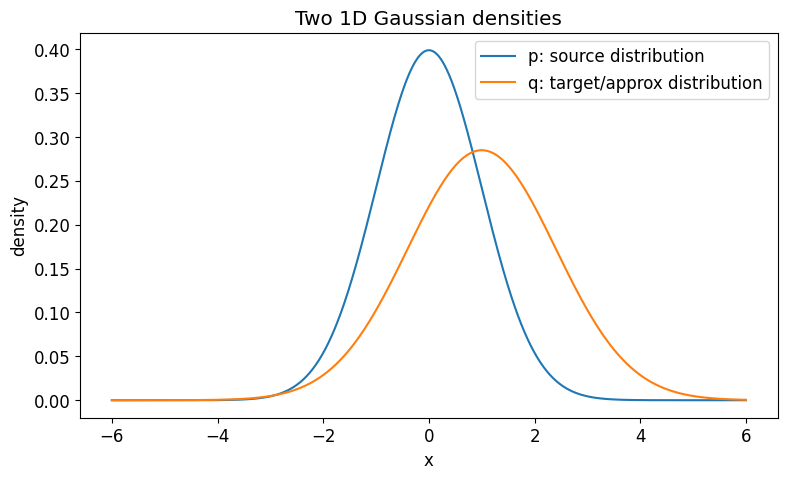

In [4]:
fig, ax = plt.subplots()
ax.plot(x_grid, p_pdf, label="p: source distribution")
ax.plot(x_grid, q_pdf, label="q: target/approx distribution")
ax.set_title("Two 1D Gaussian densities")
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.legend()
plt.show()

---

## Section 2: TODO 1 - Derive KL for 1D Gaussians by Hand

Start from

$$
D_{KL}(p\|q)
=
\mathbb{E}_{p}\left[\log p(X)-\log q(X)\right].
$$

Use your Week 3 Gaussian log-density:

$$
\log N(x;\mu,\sigma^2)
=
-\log(\sigma\sqrt{2\pi})
-
\frac{(x-\mu)^2}{2\sigma^2}.
$$

### TODO 1.1 - Completed by hand

Write $\log p(X)$ and $\log q(X)$ explicitly.

Your work:

$$
\log p(X)
=
-\log(\sigma_p\sqrt{2\pi})
-
\frac{(X-\mu_p)^2}{2\sigma_p^2}
$$

$$
\log q(X)
=
-\log(\sigma_q\sqrt{2\pi})
-
\frac{(X-\mu_q)^2}{2\sigma_q^2}
$$

### TODO 1.2 - Completed by hand

Substitute those into $\mathbb{E}_p[\log p(X)-\log q(X)]$.

Your work:

$$
\begin{aligned}
D_{KL}(p\|q)
&=
\mathbb{E}_p\left[
-\log(\sigma_p\sqrt{2\pi})
-\frac{(X-\mu_p)^2}{2\sigma_p^2}
+\log(\sigma_q\sqrt{2\pi})
+\frac{(X-\mu_q)^2}{2\sigma_q^2}
\right] \\
&=
\log\left(\frac{\sigma_q}{\sigma_p}\right)
-
\frac{1}{2\sigma_p^2}\mathbb{E}_p[(X-\mu_p)^2]
+
\frac{1}{2\sigma_q^2}\mathbb{E}_p[(X-\mu_q)^2].
\end{aligned}
$$

### TODO 1.3 - Completed by hand

Use these facts under $X\sim p$:

$$
\mathbb{E}_p[X-\mu_p]=0,
\qquad
\mathbb{E}_p[(X-\mu_p)^2]=\sigma_p^2.
$$

You will also need this quantity:

$$
\mathbb{E}_p[(X-\mu_q)^2].
$$

Hint: rewrite

$$
X-\mu_q=(X-\mu_p)+(\mu_p-\mu_q).
$$

Your work:

$$
\begin{aligned}
\mathbb{E}_p[(X-\mu_q)^2]
&=
\mathbb{E}_p\left[((X-\mu_p)+(\mu_p-\mu_q))^2\right] \\
&=
\mathbb{E}_p[(X-\mu_p)^2]
+2(\mu_p-\mu_q)\mathbb{E}_p[X-\mu_p]
+(\mu_p-\mu_q)^2 \\
&=
\sigma_p^2+(\mu_p-\mu_q)^2.
\end{aligned}
$$

### TODO 1.4 - Completed by hand

Simplify everything into one final analytic expression.

Your final formula:

$$
D_{KL}(p\|q)
=
\log\left(\frac{\sigma_q}{\sigma_p}\right)
+
\frac{\sigma_p^2+(\mu_p-\mu_q)^2}{2\sigma_q^2}
-
\frac{1}{2}.
$$

Equivalently, the cleaner single-fraction version is

$$
D_{KL}(p\|q)
=
\log\left(\frac{\sigma_q}{\sigma_p}\right)
+
\frac{\sigma_p^2+(\mu_p-\mu_q)^2-\sigma_q^2}{2\sigma_q^2}.
$$

---

## Section 3: TODO 2 - Implement the Analytic KL

Implement the formula you derived above. Keep this cell as the source of truth for the rest of the notebook.

In [16]:
def kl_gaussian_1d(mu_p, sigma_p, mu_q, sigma_q):
    """Return D_KL(N(mu_p, sigma_p^2) || N(mu_q, sigma_q^2))."""
    kl = np.log(sigma_q/sigma_p) + (sigma_p**2 + (mu_p - mu_q)**2 - sigma_q**2) / (2 * sigma_q ** 2)
    return float(kl)


same_kl = kl_gaussian_1d(0.0, 1.0, 0.0, 1.0)
shift_kl = kl_gaussian_1d(0.0, 1.0, 1.0, 1.0)
wide_kl = kl_gaussian_1d(0.0, 1.0, 0.0, 2.0)

print({"same": same_kl, "shifted_mean": shift_kl, "wider_q": wide_kl})

# Optional self-checks after completing the TODO:
assert np.isclose(same_kl, 0.0)
assert shift_kl > same_kl
assert wide_kl > same_kl

{'same': 0.0, 'shifted_mean': 0.5, 'wider_q': 0.3181471805599453}


---

## Section 4: TODO 3 - Monte Carlo KL Estimate

Monte Carlo estimate:

1. Sample $X_1,\dots,X_n\sim p$.
2. Compute $\log p(X_i)-\log q(X_i)$ for each sample.
3. Average those values.

This estimates the same expectation in the KL definition.

In [17]:
def monte_carlo_kl(mu_p, sigma_p, mu_q, sigma_q, n_samples, rng):
    """Estimate D_KL(p || q) by sampling from p."""
    samples = rng.normal(loc=mu_p, scale=sigma_p, size=n_samples)

    # compute log p(samples) - log q(samples), then average.
    log_p = normal_logpdf(x=samples, mu=mu_p, sigma=sigma_p)
    log_q = normal_logpdf(x=samples, mu=mu_q, sigma=sigma_q)
    log_diff = log_p - log_q
    estimate = np.average(log_diff)
    return float(estimate)


sample_sizes = [100, 1_000, 10_000, 100_000]
mc_rows = []
for n in sample_sizes:
    estimate = monte_carlo_kl(
        config["p"]["mu"],
        config["p"]["sigma"],
        config["q"]["mu"],
        config["q"]["sigma"],
        n,
        rng,
    )
    mc_rows.append({"n_samples": n, "mc_kl": estimate})

print(mc_rows)

# Optional self-check after completing TODO 2 and TODO 3:
analytic = kl_gaussian_1d(config["p"]["mu"], config["p"]["sigma"], config["q"]["mu"], config["q"]["sigma"])
print(analytic)
assert abs(mc_rows[-1]["mc_kl"] - analytic) < 0.03

[{'n_samples': 100, 'mc_kl': 0.4170474298842182}, {'n_samples': 1000, 'mc_kl': 0.35978427306332095}, {'n_samples': 10000, 'mc_kl': 0.3487348954365215}, {'n_samples': 100000, 'mc_kl': 0.34712941000912934}]
0.346676318253866


---

## Section 5: TODO 4 - Histogram-Based KL Estimate

Histogram KL turns samples into approximate discrete distributions.

This is intentionally fragile. Your job is to see how much the estimate depends on binning and smoothing.

Use common bins for samples from $p$ and $q$. Then estimate probabilities per bin and compute the discrete KL sum.

In [11]:
samples_p = rng.normal(config["p"]["mu"], config["p"]["sigma"], size=config["n_samples"])
samples_q = rng.normal(config["q"]["mu"], config["q"]["sigma"], size=config["n_samples"])


def histogram_kl(samples_p, samples_q, bins, eps=1e-12):
    """Estimate KL from two sample sets using shared histogram bins."""
    counts_p, _ = np.histogram(samples_p, bins=bins)
    counts_q, _ = np.histogram(samples_q, bins=bins)

    # convert counts to probability vectors.
    p_hat = counts_p / np.sum(counts_p)
    q_hat = counts_q / np.sum(counts_q)

    # TODO: add eps smoothing if needed, renormalize, and compute sum p_hat * log(p_hat / q_hat).
    p_hat_smooth = p_hat + eps
    q_hat_smooth = q_hat + eps
    p_hat_renormalized = p_hat_smooth / np.sum(p_hat_smooth)
    q_hat_renormalized = q_hat_smooth / np.sum(q_hat_smooth)
    kl_bin_contribution = p_hat_renormalized * np.log(p_hat_renormalized / q_hat_renormalized)
    estimate = np.sum(kl_bin_contribution)
    return float(estimate)


bins = np.linspace(-6, 6, 51)
hist_kl = histogram_kl(samples_p, samples_q, bins)
hist_kl

# Optional self-check after completing the TODO:
assert np.isfinite(hist_kl)
assert hist_kl >= 0

---

## Section 6: TODO 5 - Sensitivity to Binning

Compare histogram KL estimates for several bin counts. The point is not to find the perfect bin count; the point is to notice that empirical distribution estimates have knobs.

In [12]:
bin_counts = [20, 50, 100, 200]
hist_rows = []

for count in bin_counts:
    bins = np.linspace(-6, 6, count + 1)
    estimate = histogram_kl(samples_p, samples_q, bins)
    hist_rows.append({"bin_count": count, "hist_kl": estimate})

hist_rows

[{'bin_count': 20, 'hist_kl': 0.34475064076244133},
 {'bin_count': 50, 'hist_kl': 0.35155974350682156},
 {'bin_count': 100, 'hist_kl': 0.354820465854957},
 {'bin_count': 200, 'hist_kl': 0.3633841105763961}]

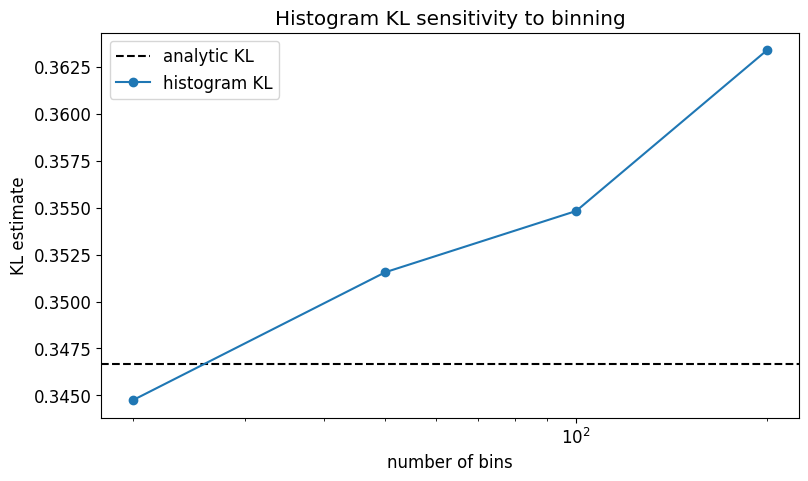

In [13]:
# TODO: after TODO 2 and TODO 5 are complete, plot analytic KL vs histogram estimates.
analytic = kl_gaussian_1d(config["p"]["mu"], config["p"]["sigma"], config["q"]["mu"], config["q"]["sigma"])
xs = [row["bin_count"] for row in hist_rows]
ys = [row["hist_kl"] for row in hist_rows]

fig, ax = plt.subplots()
ax.axhline(analytic, color="black", linestyle="--", label="analytic KL")
ax.plot(xs, ys, marker="o", label="histogram KL")
ax.set_xscale("log")
ax.set_xlabel("number of bins")
ax.set_ylabel("KL estimate")
ax.set_title("Histogram KL sensitivity to binning")
ax.legend()
plt.show()

---

## Section 7: TODO 6 - Reflection

Answer these in your own words after the code works.

1. Why is $D_{KL}(p\|q)$ not usually the same as $D_{KL}(q\|p)$?
2. Which estimate was more stable: Monte Carlo KL or histogram KL? Why?
3. Why would histogram KL become much harder in high dimensions?
4. How does this connect to the idea of matching a simple Gaussian distribution to a complicated data distribution?

Your reflection:

- $D_{KL}(p\|q)$ is not usually the same as $D_{KL}(q\|p)$ because the expectation is taken under the first distribution. In $D_{KL}(p\|q)$ we average $\log p(X)-\log q(X)$ over samples from $p$; in $D_{KL}(q\|p)$ we average the opposite log-ratio over samples from $q$. Those two averages emphasize different regions of the line. For the configured Gaussians, $D_{KL}(p\|q)=0.3467$ but $D_{KL}(q\|p)=0.6435$.
- The Monte Carlo estimate was more stable here. It estimates the same expectation as the definition by sampling from $p$, so increasing the sample size made it converge toward the analytic value. Histogram KL was in the right neighborhood in 1D, but it changed when the bin count changed because binning, finite samples, and smoothing introduce extra approximation choices.
- Histogram KL becomes much harder in high dimensions because the number of bins grows exponentially with dimension. With a fixed number of samples, most bins become empty or noisy, so the estimate can be dominated by sparsity and smoothing rather than the true density mismatch.
- This connects to distribution matching because a single simple Gaussian is only a tractable toy approximation to a complicated data distribution. Real data distributions are high-dimensional, structured, and often multi-modal, so we usually do not have a closed-form density or closed-form KL. Diffusion and flow models learn a transformation from a simple noise distribution toward the data distribution instead of trying to estimate a huge histogram directly.

---

## Takeaways

Fill this section after solving the TODOs.

- Analytic result: $D_{KL}(p\|q)=0.346676318253866$ for the configured Gaussians. Direction matters: the reverse KL for the same pair is $D_{KL}(q\|p)=0.643527763378787$.
- Empirical evidence: Monte Carlo KL approached the analytic value as the sample size increased. Histogram KL was close in this 1D example, but it drifted with the number of bins because it adds discretization and smoothing choices.
- Main pitfall: More samples help Monte Carlo, but more bins are not automatically better for histogram KL. Bin range, bin count, smoothing, and sample size interact, and this gets much worse in high dimensions.
- Connection to diffusion / flow matching: KL is one formal way to describe distribution mismatch, and KL terms appear in variational diffusion derivations. The broader intuition is that generative models learn to transform a simple base distribution, usually Gaussian noise, into a complicated data distribution without estimating a high-dimensional histogram.